# 05 Sovereignty-Embedded Earth Data Science (SEEDS)
## Tribal Data Sovereignty Toolkit

## What is SEEDS?

Sovereignty-Embedded Earth Data Science is a framework that treats technical
excellence and ethical stewardship as inseparable. Students and
researchers learn the same geospatial and data science skills taught
elsewhere, but every stage of the workflow also asks questions about
governance, consent, context, reciprocity, and long-term community benefit.

SEEDS weaves treating Indigenous Data Sovereignty into the practice of Earth data science.

This notebook demonstrates the SEEDS cycle applied to a real analysis:
drought characterization on Pine Ridge Reservation.

## The SEEDS Cycle

```
Community Question
       
Data Discovery = Stewardship Check
       
Data Preparation = Governance Check
       
Analysis = Knowledge Check
       
Visualization = Sharing Check
       
Community Decision = Future Generations
```


In [1]:
import sys
from pathlib import Path

# Walk up to find repo root
REPO_ROOT = Path().resolve()
while not (REPO_ROOT/"config"/"nation_template.yaml").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        REPO_ROOT = Path().resolve()
        break
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Toolkit root: {REPO_ROOT}")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from toolkit.sovereignty import SovereigntyContext
from toolkit.provenance  import ProvenanceBuilder, ProvenanceCatalog
from toolkit.audit       import SovereigntyAudit

ctx = SovereigntyContext.from_config(REPO_ROOT/"config"/"nation_template.yaml")
catalog = ProvenanceCatalog("SEEDS Demo for Pine Ridge Drought Analysis")
print("Ready. SEEDS cycle begins.")

Toolkit root: C:\Users\gekek\Documents\IDSov_toolkit
Ready. SEEDS cycle begins.


## Community Questions

**Technical task:** Define a climate resilience question grounded in
community need.

**Stewardship check:** Who identified this problem? Does the question
reflect community priorities? Who benefits from the answer?

In [2]:
# CUSTOMIZE HERE
QUESTION = (
    "How has drought frequency changed on Pine Ridge over the past 40 years, "
    "and is it getting worse?"
)
STUDY_AREA  = ctx.config.territory
BENEFIT     = "Drought early warning for Tribal water managers and ranchers"

print("COMMUNITY QUESTION")
print(f"Nation      : {ctx.config.name}")
print(f"Territory   : {STUDY_AREA}")
print(f"Question    : {QUESTION}")
print(f"Benefit     : {BENEFIT}")
print()
print("Stewardship check:")
print("  Is this question grounded in a community need? [yes]")
print("  Has the Nation approved this research focus?   [document in MOU]")
print("  Will the Nation receive findings first?        [yes]")

COMMUNITY QUESTION
Nation      : Oglala Lakota
Territory   : Pine Ridge Reservation
Question    : How has drought frequency changed on Pine Ridge over the past 40 years, and is it getting worse?
Benefit     : Drought early warning for Tribal water managers and ranchers

Stewardship check:
  Is this question grounded in a community need? [yes]
  Has the Nation approved this research focus?   [document in MOU]
  Will the Nation receive findings first?        [yes]


## Data Discovery and Stewardship Check

In [3]:
import requests, re
from io import StringIO

# Load NOAA PDSI for Pine Ridge climate divisions
print("Loading NOAA PDSI drought data...")
NOAA_BASE = "https://www.ncei.noaa.gov/pub/data/cirs/climdiv"
try:
    dir_r   = requests.get(NOAA_BASE + "/", timeout=30)
    matches = re.findall(r"climdiv-pdsidv-v1\.0\.0-\d{8}", dir_r.text)
    fname   = matches[-1] if matches else "climdiv-pdsidv-v1.0.0-20250108"
except Exception:
    fname = "climdiv-pdsidv-v1.0.0-20250108"

r = requests.get(f"{NOAA_BASE}/{fname}", timeout=120)

records = []
for line in r.text.strip().splitlines():
    parts = line.split()
    if len(parts) < 13: continue
    code = parts[0]
    if len(code) != 10: continue
    st, div_s, elem, yr_s = code[0:2], code[2:4], code[4:6], code[6:10]
    if st != "39" or elem != "05": continue
    try:
        div, year = int(div_s), int(yr_s)
    except ValueError:
        continue
    if div not in [7, 8] or year < 1980: continue
    for mo, raw in enumerate(parts[1:13], 1):
        try:
            val = float(raw)
            pdsi = np.nan if val <= -99 else val
        except ValueError:
            pdsi = np.nan
        records.append({"year": year, "month": mo, "pdsi": pdsi,
                        "date": pd.Timestamp(year=year, month=mo, day=1)})

pdsi_df = (pd.DataFrame(records)
           .dropna(subset=["pdsi"])
           .groupby("date")["pdsi"].mean()
           .reset_index()
           .rename(columns={"pdsi": "pdsi_avg"}))
pdsi_df["year"] = pdsi_df["date"].dt.year

print(f"Loaded: {len(pdsi_df):,} monthly PDSI values")
print(f"Range: {pdsi_df['date'].min().date()} to {pdsi_df['date'].max().date()}")

# Stewardship check — attach provenance immediately
record = (
    ProvenanceBuilder("noaa-pdsi-pine-ridge")
    .for_nation(ctx)
    .for_dataset("NOAA PDSI for Pine Ridge Climate Divisions 7-8")
    .from_source("noaa_pdsi")
    .step("Downloaded from NOAA Climate Division data (climdiv-pdsidv)")
    .step("Filtered to SD state code 39, divisions 7 and 8")
    .step("Averaged across both divisions for single Pine Ridge series")
    .classify("PUBLIC")
    .note("NOAA PDSI computed from sparse weather station network. "
          "Station density on Pine Ridge is lower than surrounding counties.")
    .build()
)
catalog.add(record)
print("Stewardship check: provenance record attached.")

Loading NOAA PDSI drought data...
Loaded: 558 monthly PDSI values
Range: 1980-01-01 to 2026-06-01
Stewardship check: provenance record attached.


## Analysis and Knowledge Check

In [4]:
from scipy import stats

# Annual drought statistics
annual = pdsi_df.groupby("year").agg(
    mean_pdsi       = ("pdsi_avg","mean"),
    drought_months  = ("pdsi_avg", lambda x: (x <= -2.0).sum()),
    extreme_months  = ("pdsi_avg", lambda x: (x <= -4.0).sum()),
).reset_index()

# Trend analysis
slope, intercept, r, p, se = stats.linregress(
    annual["year"], annual["drought_months"]
)
print("DROUGHT TREND ANALYSIS")
print(f"Drought months/year trend: {slope*10:+.2f} per decade (p={p:.3f})")
sig = "statistically significant" if p < 0.05 else "not statistically significant"
print(f"Significance: {sig}")
print()
recent   = annual[annual["year"] >= 2010]["drought_months"].mean()
historic = annual[annual["year"] <  2010]["drought_months"].mean()
print(f"Historical mean drought months/year (1980-2009): {historic:.1f}")
print(f"Recent mean drought months/year   (2010-present): {recent:.1f}")
print(f"Change: {recent-historic:+.1f} months/year")
print()
print("Knowledge check:")
print("  Does this analysis capture what the community means by drought?")
print("  What traditional knowledge about drought is not in the data?")
print("  Would community observations improve or change this result?")

DROUGHT TREND ANALYSIS
Drought months/year trend: -0.29 per decade (p=0.243)
Significance: not statistically significant

Historical mean drought months/year (1980-2009): 1.5
Recent mean drought months/year   (2010-present): 0.9
Change: -0.6 months/year

Knowledge check:
  Does this analysis capture what the community means by drought?
  What traditional knowledge about drought is not in the data?
  Would community observations improve or change this result?


## Visualization and Sharing Check

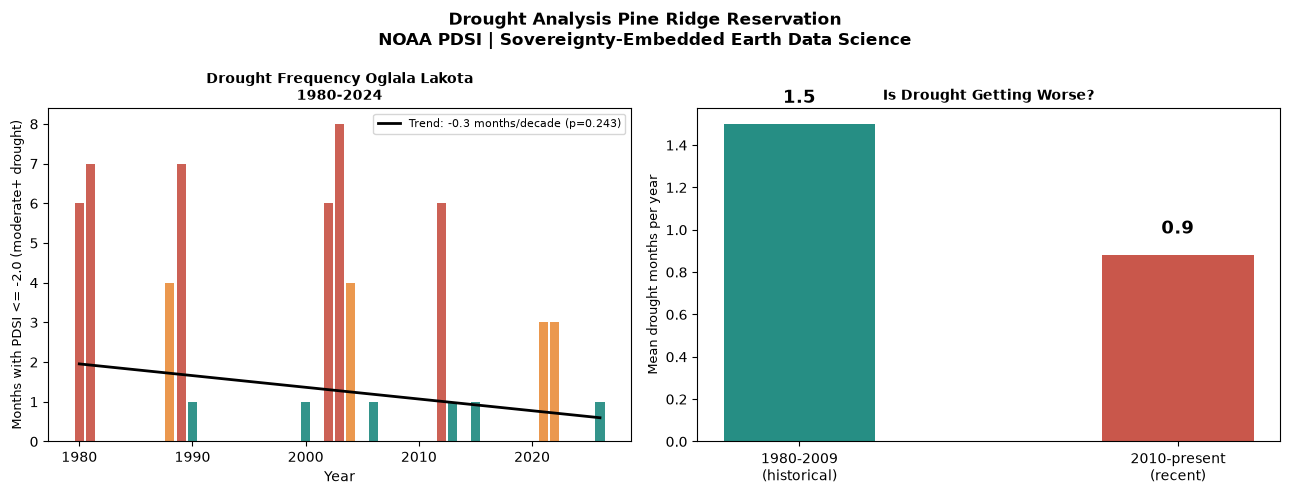

Sharing check:
  Who is the intended audience for this visualization?
  Does this map or chart reveal any sensitive locations?
  Has the Nation reviewed this before external sharing?


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
TEAL = "#007A6E"; TERRACOTTA = "#C0392B"; ORANGE = "#E67E22"

# Drought months per year
ax = axes[0]
ax.bar(annual["year"], annual["drought_months"],
       color=[TERRACOTTA if v >= 6 else ORANGE if v >= 3 else TEAL
              for v in annual["drought_months"]],
       alpha=0.8, width=0.8)
xs = annual["year"].values.astype(float)
ax.plot(xs, slope*xs+intercept, color="black", linewidth=2,
        label=f"Trend: {slope*10:+.1f} months/decade (p={p:.3f})")
ax.set_ylabel("Months with PDSI <= -2.0 (moderate+ drought)", fontsize=9)
ax.set_xlabel("Year")
ax.set_title(f"Drought Frequency {ctx.config.name}\n1980-2024",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8)

# Recent vs historical comparison
ax = axes[1]
bars = ax.bar(["1980-2009\n(historical)", "2010-present\n(recent)"],
              [historic, recent], color=[TEAL, TERRACOTTA], alpha=0.85, width=0.4)
for bar, val in zip(bars, [historic, recent]):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.1, f"{val:.1f}",
            ha="center", fontsize=13, fontweight="bold")
ax.set_ylabel("Mean drought months per year", fontsize=9)
ax.set_title("Is Drought Getting Worse?", fontsize=10, fontweight="bold")

plt.suptitle(f"Drought Analysis {ctx.config.territory}\n"
             "NOAA PDSI | Sovereignty-Embedded Earth Data Science",
             fontsize=12, fontweight="bold")
plt.tight_layout()

from pathlib import Path
out = Path(REPO_ROOT)/"outputs"
out.mkdir(exist_ok=True)
fig.savefig(out/"seeds_drought_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("Sharing check:")
print("  Who is the intended audience for this visualization?")
print("  Does this map or chart reveal any sensitive locations?")
print("  Has the Nation reviewed this before external sharing?")

## Community Decision and Future Generations

In [6]:
# Generate the governance report for this analysis
report = ctx.governance_report(
    dataset_name  = "Pine Ridge Drought Analysis",
    source_keys   = ["noaa_pdsi"],
    classification= "PUBLIC",
    analyst_name  = "Lilly Jones, Daear Consulting, LLC",
    notes = (
        f"Drought months per year trend: {slope*10:+.2f} per decade (p={p:.3f}). "
        f"Recent period (2010-present) shows {recent-historic:+.1f} more drought "
        f"months per year than the historical baseline. "
        f"Findings returned to Tribal Natural Resources Department before publication."
    ),
)
print(report)

# Save provenance catalog
catalog.save(out / "seeds_provenance_catalog.json")
print("\nSEEDS cycle complete.")
print(f"  Analysis figure: outputs/seeds_drought_analysis.png")
print(f"  Provenance catalog: outputs/seeds_provenance_catalog.json")

DATA GOVERNANCE REPORT
Dataset       : Pine Ridge Drought Analysis
Nation        : Oglala Lakota
Territory     : Pine Ridge Reservation
Classification: PUBLIC
Report date   : 2026-07-16
Analyst       : Lilly Jones, Daear Consulting, LLC

TERRITORIAL PROVENANCE
  Treaty    : 1868 Fort Laramie Treaty
  Territory : Great Sioux Reservation, including He Sapa (Black Hills)
  Status    : The lands of Pine Ridge Reservation are the sovereign territory of the Oglala Lakota people. Federal data collection on these lands does not transfer authority over Tribal resources to federal agencies or researchers.
  Citation  : United States v. Sioux Nation of Indians, 448 U.S. 371 (1980)

GOVERNANCE FRAMEWORKS
  OCAP              : https://fnigc.ca/ocap-training/
  CARE              : https://www.gida-global.org/care
  FAIR              : https://www.go-fair.org/fair-principles/
  IEEE_2890         : https://standards.ieee.org/ieee/2890/10318/

DATA SOURCES
  NOAA Climate Division PDSI
    Steward : Nat